<a href="https://colab.research.google.com/github/jahern19/Stock-analysis/blob/main/comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Quantitative Analysis

In [ ]:
!pip install yfinance matplotlib seaborn --quiet

Data Collection: Using python yfinance historical data

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

In [3]:
stocks = ["AAPL", "MSFT", "NVDA", "SPY"]

data = yf.download(stocks, start="2023-01-01")["Close"]

data.head()

/tmp/ipykernel_14890/954484185.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start="2023-01-01")["Close"]
[*********************100%***********************]  4 of 4 completed


Ticker,AAPL,MSFT,NVDA,SPY
Date,,,,
2023-01-03,122.982719,233.452820,14.299910,365.072052
2023-01-04,124.251183,223.240829,14.733452,367.890472
2023-01-05,122.933556,216.624466,14.249962,363.691589
2023-01-06,127.456787,219.177475,14.843336,372.031830
2023-01-09,127.977943,221.311462,15.611527,371.820953


Comparitive Performance Analysis: NVDA has shown the most growth by a significant margin

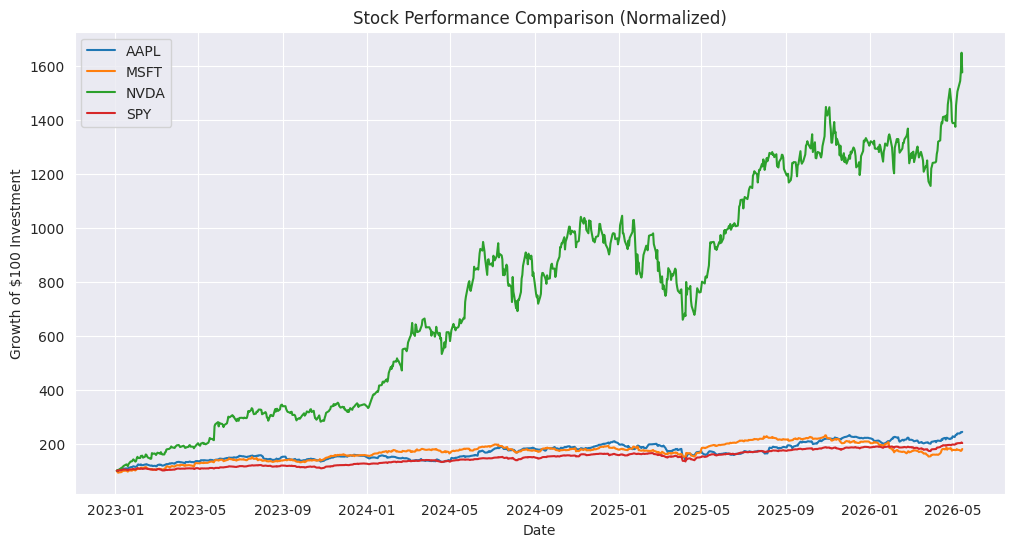

In [4]:
normalized = data / data.iloc[0] * 100

plt.figure(figsize=(12,6))

for stock in normalized.columns:
    plt.plot(normalized.index, normalized[stock], label=stock)

plt.title("Stock Performance Comparison (Normalized)")
plt.xlabel("Date")
plt.ylabel("Growth of $100 Investment")
plt.legend()
plt.show()

Visualization of portfolio allocation

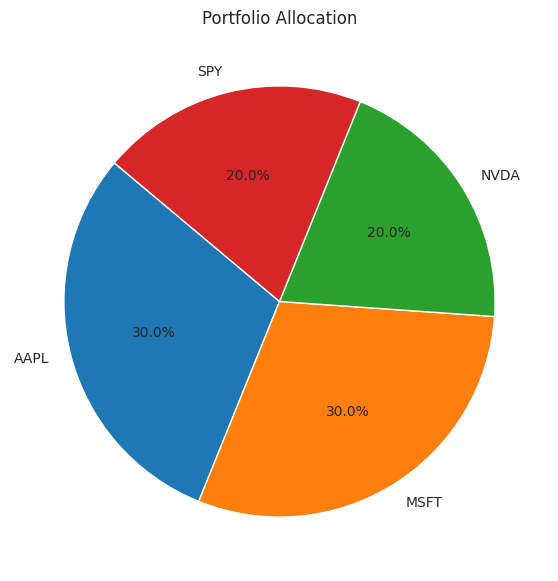

In [6]:
weights = {
    "AAPL": 30,
    "MSFT": 30,
    "NVDA": 20,
    "SPY": 20
}

plt.figure(figsize=(7,7))

plt.pie(
    weights.values(),
    labels=weights.keys(),
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Portfolio Allocation")
plt.show()

Volatility Analysis: NVDA shows most volatility but most return

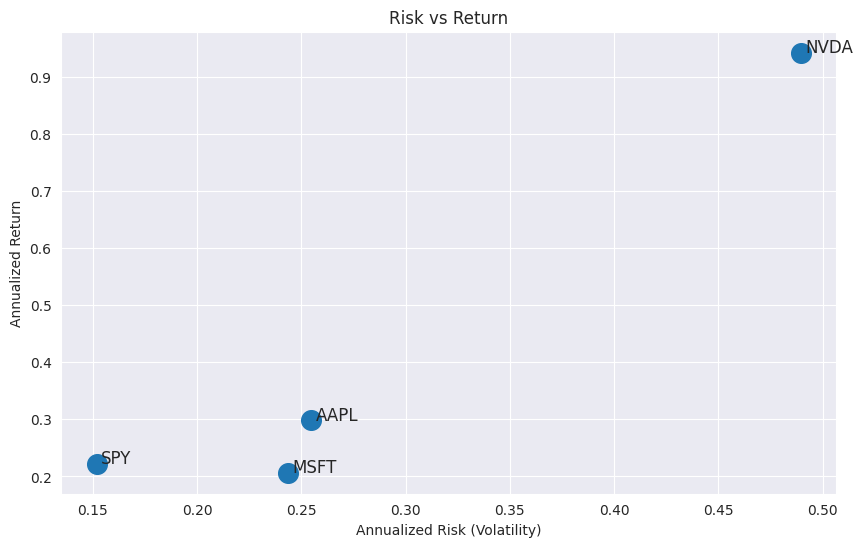

In [7]:
returns = data.pct_change().dropna()

annual_return = returns.mean() * 252
risk = returns.std() * np.sqrt(252)

metrics = pd.DataFrame({
    "Return": annual_return,
    "Risk": risk
})

plt.figure(figsize=(10,6))

plt.scatter(metrics["Risk"], metrics["Return"], s=200)

for stock in metrics.index:
    plt.text(
        metrics.loc[stock, "Risk"] + 0.002,
        metrics.loc[stock, "Return"],
        stock,
        fontsize=12
    )

plt.title("Risk vs Return")
plt.xlabel("Annualized Risk (Volatility)")
plt.ylabel("Annualized Return")

plt.show()

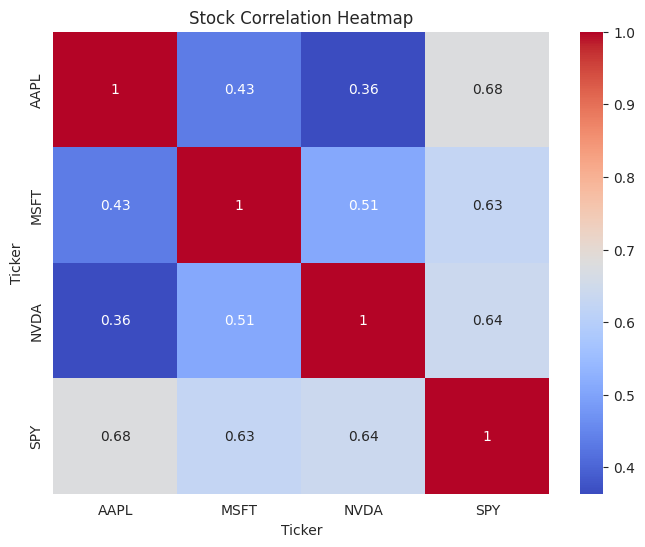

In [8]:
plt.figure(figsize=(8,6))

sns.heatmap(returns.corr(), annot=True, cmap="coolwarm")

plt.title("Stock Correlation Heatmap")
plt.show()

Conclusion: Technology has shown highest volatility and reurns